In [2]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.9 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Generalized Feedforward Neural Network on MNIST

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# --------------------------------------------------
# 1. Set device
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# --------------------------------------------------
# 2. Load MNIST dataset
# --------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# --------------------------------------------------
# 3. Create a generalized FFN class
# --------------------------------------------------

class GeneralizedFFN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_layers,
        output_size,
        activation_function=nn.ReLU
    ):
        super().__init__()

        layers = []

        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(activation_function())
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, output_size))

        self.flatten = nn.Flatten()
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)



Using device: cpu
Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████████████████████| 9912422/9912422 [00:01<00:00, 7786448.62it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 774519.94it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████████████████████| 1648877/1648877 [00:00<00:00, 9998541.83it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████| 4542/4542 [00:00<00:00, 5446120.29it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



GeneralizedFFN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)
Epoch 1/5 | Loss: 0.3820 | Train Acc: 88.17% | Test Acc: 93.52%
Epoch 2/5 | Loss: 0.1663 | Train Acc: 94.86% | Test Acc: 95.82%
Epoch 3/5 | Loss: 0.1252 | Train Acc: 96.07% | Test Acc: 96.27%
Epoch 4/5 | Loss: 0.0984 | Train Acc: 96.93% | Test Acc: 96.47%
Epoch 5/5 | Loss: 0.0839 | Train Acc: 97.30% | Test Acc: 97.57%


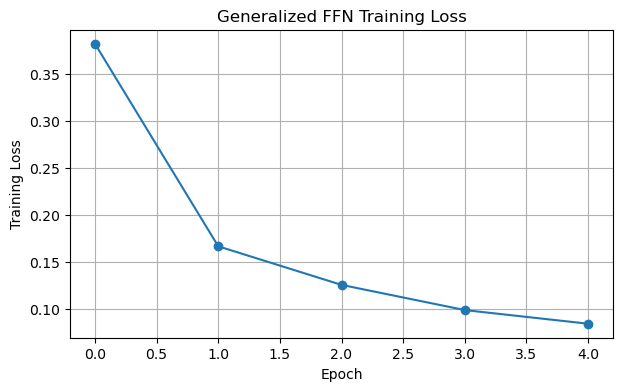

In [4]:

# --------------------------------------------------
# 4. Build model from configurable architecture
# --------------------------------------------------

model = GeneralizedFFN(
    input_size=28 * 28,
    hidden_layers=[256, 128, 64],
    output_size=10,
    activation_function=nn.ReLU
).to(device)

print(model)


# --------------------------------------------------
# 5. Define reusable training function
# --------------------------------------------------

def train_model(
    model,
    train_loader,
    test_loader,
    loss_function,
    optimizer,
    num_epochs
):

    train_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        average_loss = total_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        model.eval()

        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                predictions = torch.argmax(outputs, dim=1)

                test_correct += (predictions == labels).sum().item()
                test_total += labels.size(0)

        test_accuracy = 100 * test_correct / test_total

        train_losses.append(average_loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Loss: {average_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Acc: {test_accuracy:.2f}%"
        )

    return train_losses, train_accuracies, test_accuracies


# --------------------------------------------------
# 6. Train generalized FFN
# --------------------------------------------------

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 5

train_losses, train_accuracies, test_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=num_epochs
)


# --------------------------------------------------
# 7. Visualize training loss
# --------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Generalized FFN Training Loss")
plt.grid(True)
plt.show()


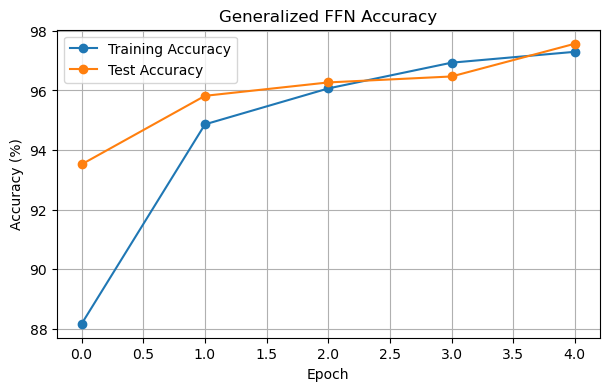

In [5]:


# --------------------------------------------------
# 8. Visualize accuracy
# --------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(train_accuracies, marker="o", label="Training Accuracy")
plt.plot(test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Generalized FFN Accuracy")
plt.legend()
plt.grid(True)
plt.show()



In [6]:

# --------------------------------------------------
# 9. Compare multiple FFN architectures
# --------------------------------------------------

architectures = {
    "Small FFN": [64],
    "Medium FFN": [128, 64],
    "Large FFN": [256, 128, 64]
}

results = []

for name, hidden_layers in architectures.items():

    print(f"\nTraining {name}: {hidden_layers}")

    model = GeneralizedFFN(
        input_size=28 * 28,
        hidden_layers=hidden_layers,
        output_size=10
    ).to(device)

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, train_accuracies, test_accuracies = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        loss_function=loss_function,
        optimizer=optimizer,
        num_epochs=5
    )

    results.append({
        "Model": name,
        "Architecture": hidden_layers,
        "Final Train Accuracy": train_accuracies[-1],
        "Final Test Accuracy": test_accuracies[-1]
    })


# --------------------------------------------------
# 10. Summary table
# --------------------------------------------------

import pandas as pd

results_df = pd.DataFrame(results)
results_df


Training Small FFN: [64]
Epoch 1/5 | Loss: 0.4369 | Train Acc: 87.40% | Test Acc: 91.83%
Epoch 2/5 | Loss: 0.2497 | Train Acc: 92.75% | Test Acc: 93.69%
Epoch 3/5 | Loss: 0.1884 | Train Acc: 94.45% | Test Acc: 95.53%
Epoch 4/5 | Loss: 0.1532 | Train Acc: 95.39% | Test Acc: 95.40%
Epoch 5/5 | Loss: 0.1352 | Train Acc: 95.93% | Test Acc: 96.41%

Training Medium FFN: [128, 64]
Epoch 1/5 | Loss: 0.3819 | Train Acc: 88.65% | Test Acc: 92.00%
Epoch 2/5 | Loss: 0.1840 | Train Acc: 94.50% | Test Acc: 94.87%
Epoch 3/5 | Loss: 0.1332 | Train Acc: 95.88% | Test Acc: 95.84%
Epoch 4/5 | Loss: 0.1093 | Train Acc: 96.64% | Test Acc: 96.23%
Epoch 5/5 | Loss: 0.0945 | Train Acc: 97.04% | Test Acc: 96.57%

Training Large FFN: [256, 128, 64]
Epoch 1/5 | Loss: 0.3803 | Train Acc: 88.10% | Test Acc: 94.06%
Epoch 2/5 | Loss: 0.1639 | Train Acc: 94.93% | Test Acc: 95.86%
Epoch 3/5 | Loss: 0.1236 | Train Acc: 96.14% | Test Acc: 95.50%
Epoch 4/5 | Loss: 0.0967 | Train Acc: 96.97% | Test Acc: 96.16%
Epoch 5/5 

,Model,Architecture,Final Train Accuracy,Final Test Accuracy
0,Small FFN,[64],95.933333,96.41
1,Medium FFN,"[128, 64]",97.038333,96.57
2,Large FFN,"[256, 128, 64]",97.376667,96.82
